# Unsupervised Machine Learning: K-Means and DBSCAN

This notebook introduces two common clustering algorithms:

1. **K-Means** — groups records around moving centroids.
2. **K-Means anomaly detection** — detects unusual records using distance from the nearest centroid.
3. **DBSCAN** — groups dense regions and can mark outliers as noise.

We will use the Iris dataset because it is small, visual, and easy to understand.

Even though Iris has true labels, clustering is still unsupervised here: the algorithms do **not** use those labels during training. We use labels only for interpretation after clustering.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load the Iris dataset

Iris contains 150 flower records described by four numeric features:

- sepal length,
- sepal width,
- petal length,
- petal width.

For visual explanations, we will mostly use two features: **petal length** and **petal width**.

In [15]:
iris = load_iris()
X_all = iris.data
y_true = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print("Feature names:", feature_names)
print("Class names:", class_names)
print("X shape:", X_all.shape)

# Select two highly informative features for 2D visualization
selected_features = [2, 3]  # petal length, petal width
X = X_all[:, selected_features]
selected_feature_names = [feature_names[i] for i in selected_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']
X shape: (150, 4)


## 2. Visualize the data

The algorithms will only see feature values. The colors below use the true species labels only so we can understand the structure of the dataset.

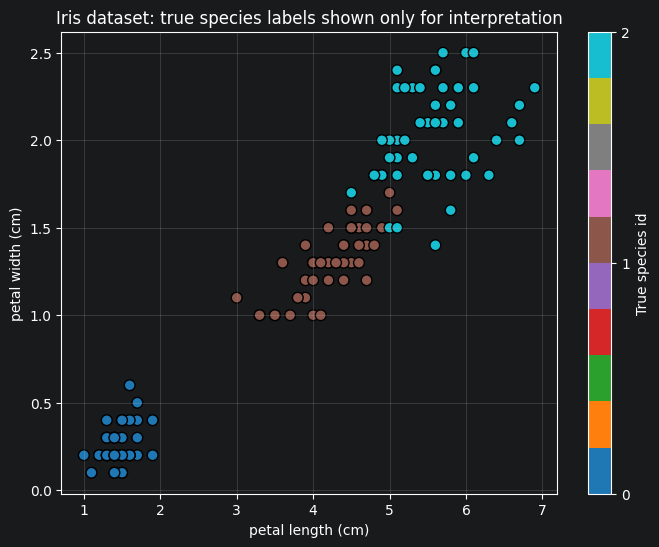

In [16]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_true, s=60, cmap='tab10', edgecolor='k')
plt.xlabel(selected_feature_names[0])
plt.ylabel(selected_feature_names[1])
plt.title('Iris dataset: true species labels shown only for interpretation')
plt.grid(alpha=0.3)
plt.colorbar(scatter, ticks=[0, 1, 2], label='True species id')
plt.show()

# Part A: K-Means

K-Means tries to find `k` cluster centers called **centroids**.

The algorithm repeats two steps:

1. Assign each point to the nearest centroid.
2. Move each centroid to the mean position of assigned points.

The objective is to reduce within-cluster squared distances.

## 3. Manual K-Means iterations for visualization

Scikit-learn hides the internal iterations. For teaching, we implement a small manual version to show how centroids move after several steps.

In [17]:
def assign_clusters(X_data, centroids):
    distances = np.linalg.norm(X_data[:, None, :] - centroids[None, :, :], axis=2)
    return np.argmin(distances, axis=1)


def update_centroids(X_data, labels, k, old_centroids):
    new_centroids = []
    for cluster_id in range(k):
        points = X_data[labels == cluster_id]
        if len(points) == 0:
            # If a centroid gets no points, keep its previous position.
            new_centroids.append(old_centroids[cluster_id])
        else:
            new_centroids.append(points.mean(axis=0))
    return np.array(new_centroids)


def run_manual_kmeans(X_data, k=3, n_iterations=6, random_state=42):
    rng = np.random.default_rng(random_state)
    initial_indices = rng.choice(len(X_data), size=k, replace=False)
    centroids = X_data[initial_indices]
    history = []

    for iteration in range(n_iterations + 1):
        labels = assign_clusters(X_data, centroids)
        history.append((iteration, centroids.copy(), labels.copy()))
        centroids = update_centroids(X_data, labels, k, centroids)

    return history

history = run_manual_kmeans(X_scaled, k=3, n_iterations=6, random_state=RANDOM_STATE)
print("Stored iterations:", len(history))

Stored iterations: 7


## 4. Visualize centroid movement step by step

The large X markers are centroids. Lines show how centroids move between iterations.

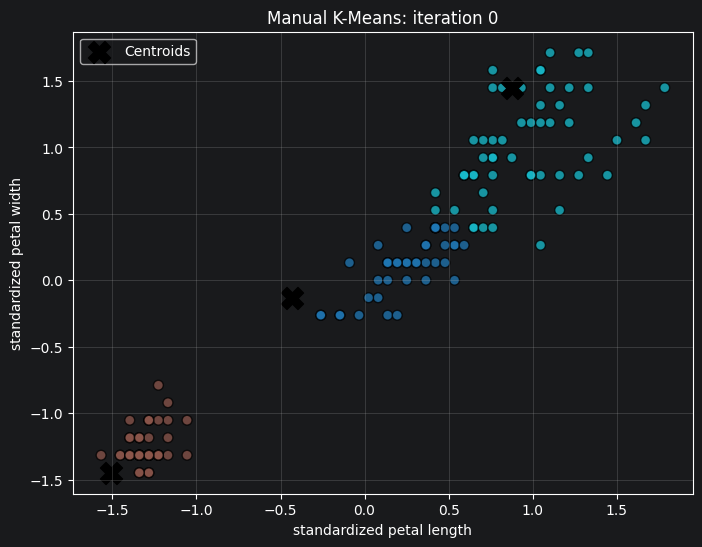

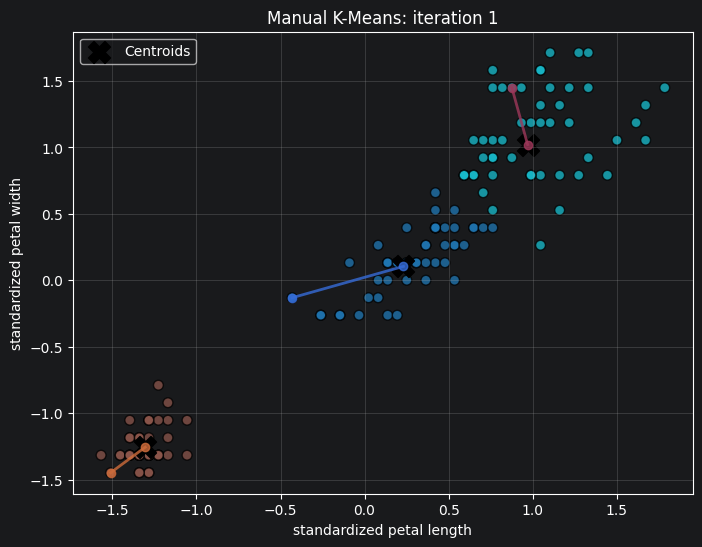

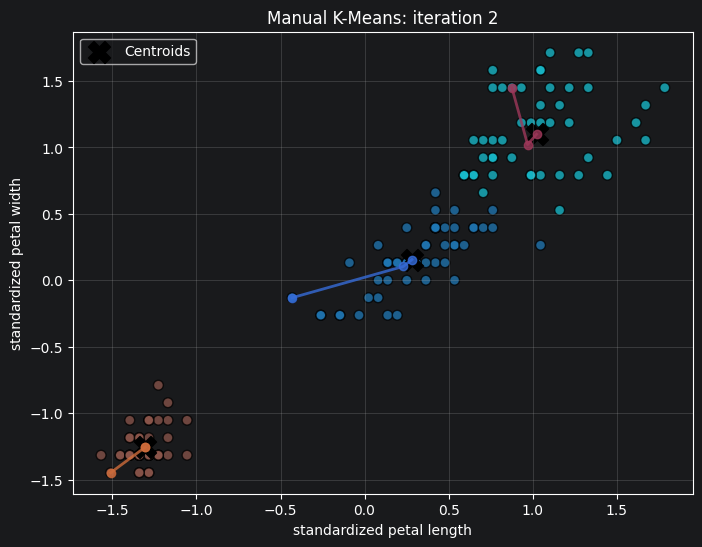

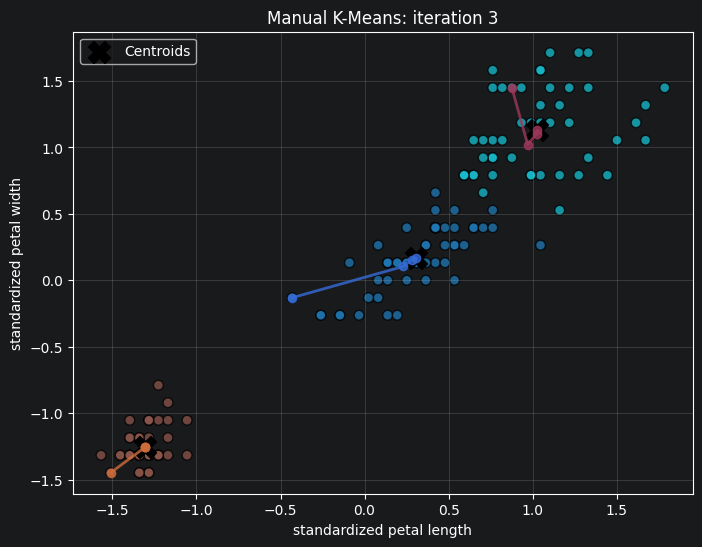

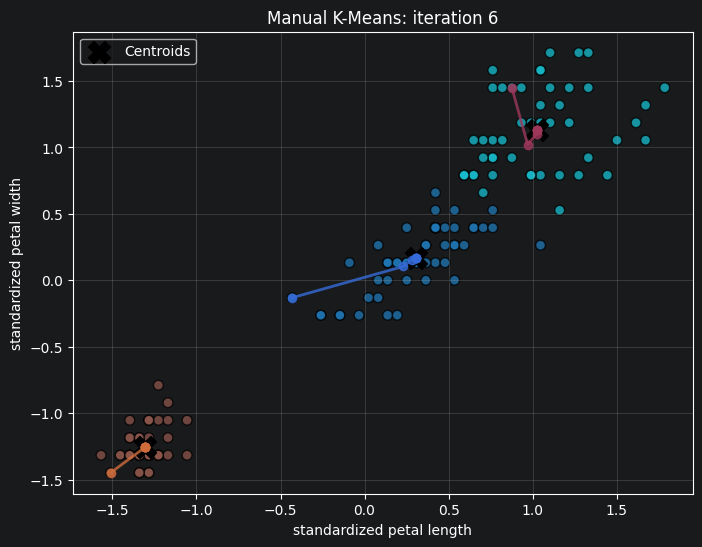

In [18]:
def plot_kmeans_iteration(X_data, history, iteration_to_show):
    iteration, centroids, labels = history[iteration_to_show]

    plt.figure(figsize=(8, 6))
    plt.scatter(X_data[:, 0], X_data[:, 1], c=labels, s=50, cmap='tab10', alpha=0.75, edgecolor='k')
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=250, c='black', label='Centroids')

    # Draw centroid paths up to this iteration
    if iteration_to_show > 0:
        for centroid_id in range(centroids.shape[0]):
            path = np.array([history[i][1][centroid_id] for i in range(iteration_to_show + 1)])
            plt.plot(path[:, 0], path[:, 1], marker='o', linewidth=2, alpha=0.8)

    plt.xlabel('standardized petal length')
    plt.ylabel('standardized petal width')
    plt.title(f'Manual K-Means: iteration {iteration}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

for i in [0, 1, 2, 3, 6]:
    plot_kmeans_iteration(X_scaled, history, i)

## 5. Final K-Means model from scikit-learn

Now we use the production-ready scikit-learn implementation.

In [19]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("Cluster counts:", np.bincount(kmeans_labels))
print("Cluster centers:", kmeans.cluster_centers_)
print("Adjusted Rand Index vs true labels:", adjusted_rand_score(y_true, kmeans_labels))
print("Silhouette score:", silhouette_score(X_scaled, kmeans_labels))

Cluster counts: [48 50 52]
Cluster centers: [[ 1.02799959  1.12797813]
 [-1.30498732 -1.25489349]
 [ 0.3058728   0.16541778]]
Adjusted Rand Index vs true labels: 0.8856970310281228
Silhouette score: 0.6741313115143868


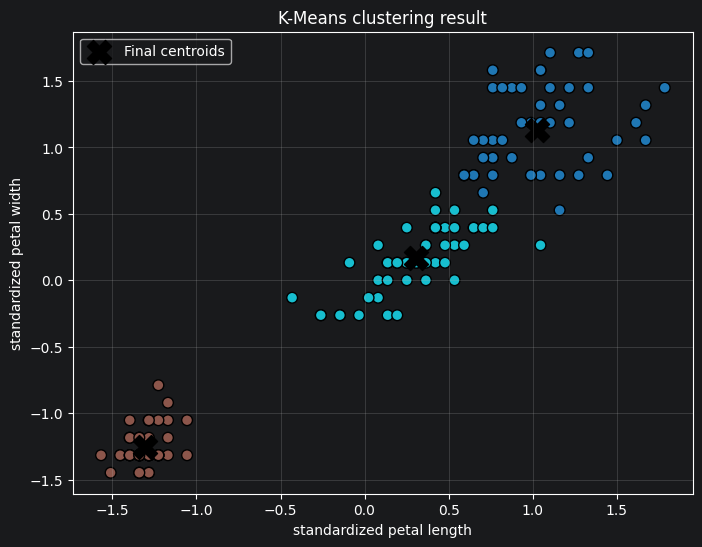

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, s=60, cmap='tab10', edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=300, c='black', label='Final centroids')
plt.xlabel('standardized petal length')
plt.ylabel('standardized petal width')
plt.title('K-Means clustering result')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Choosing `k`: elbow method

K-Means requires choosing the number of clusters `k` before training.

The elbow method checks how inertia changes as `k` increases. Inertia always decreases when we add more clusters, so we look for the point where improvement starts slowing down.

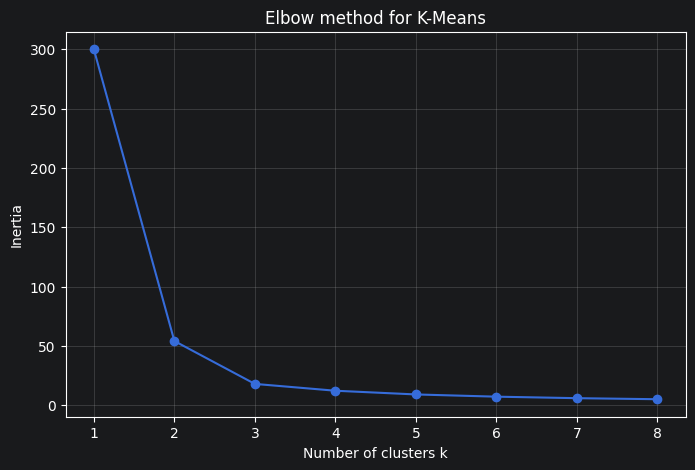

In [21]:
inertias = []
k_values = range(1, 9)

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('Elbow method for K-Means')
plt.grid(alpha=0.3)
plt.show()

# Part B: K-Means for anomaly detection

K-Means is mainly a clustering algorithm, but it can also be used for a simple form of **anomaly detection**.

The intuition is:

1. Fit K-Means on normal data.
2. For each record, calculate the distance to its nearest centroid.
3. Records far away from every centroid are suspicious.
4. Mark records as anomalies when their distance is above a chosen threshold.

This method works best when normal records form compact groups. It is less reliable when clusters have unusual shapes or very different densities.

In [23]:
# Fit a K-Means model on the 2D scaled Iris data
kmeans_for_anomaly = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
kmeans_for_anomaly.fit(X_scaled)

# Distance from every point to every centroid
all_distances = kmeans_for_anomaly.transform(X_scaled)

# The anomaly score is the distance to the closest centroid
anomaly_scores = all_distances.min(axis=1)
assigned_clusters = all_distances.argmin(axis=1)

# A simple threshold: top 5% most distant points are treated as anomalies
threshold = np.percentile(anomaly_scores, 95)
is_anomaly = anomaly_scores > threshold

print("Anomaly threshold:", round(threshold, 3))
print("Number of anomalies:", is_anomaly.sum())
print("Share of anomalies:", round(is_anomaly.mean() * 100, 2), "%")

Anomaly threshold: 0.642
Number of anomalies: 8
Share of anomalies: 5.33 %


## 7. Visualize anomalies found by K-Means

The points marked with `x` are the records farthest from their nearest centroid.

They are not necessarily *errors* in the dataset. They are simply unusual according to the K-Means distance rule.

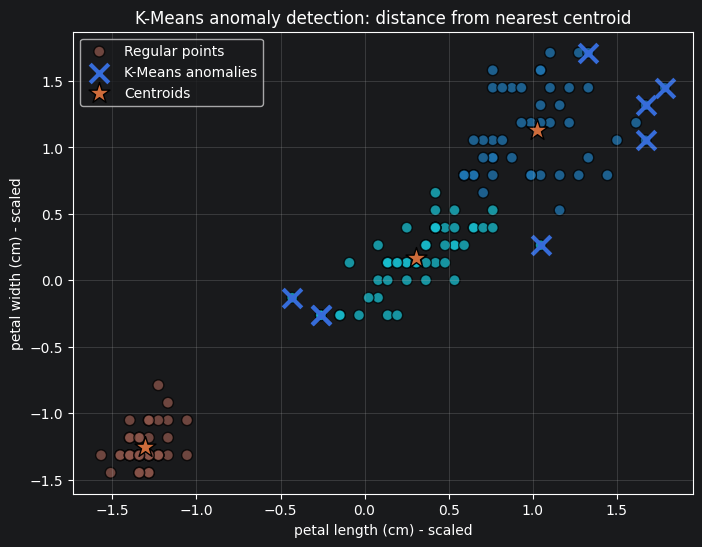

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=assigned_clusters,
    s=60,
    cmap='tab10',
    edgecolor='k',
    alpha=0.75,
    label='Regular points'
)

plt.scatter(
    X_scaled[is_anomaly, 0],
    X_scaled[is_anomaly, 1],
    s=180,
    marker='x',
    linewidths=3,
    label='K-Means anomalies'
)

plt.scatter(
    kmeans_for_anomaly.cluster_centers_[:, 0],
    kmeans_for_anomaly.cluster_centers_[:, 1],
    s=250,
    marker='*',
    edgecolor='k',
    label='Centroids'
)

plt.xlabel(selected_feature_names[0] + ' - scaled')
plt.ylabel(selected_feature_names[1] + ' - scaled')
plt.title('K-Means anomaly detection: distance from nearest centroid')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Inspect the most anomalous records

The table below shows the records with the highest distance to their closest centroid.

In a business dataset these could represent unusual customers, transactions, companies, machines, sensor readings, or documents.

In [25]:
top_n = 10
top_indices = np.argsort(anomaly_scores)[-top_n:][::-1]

print(f"Top {top_n} most anomalous records according to K-Means distance:")
print()
print("index | true species | assigned cluster | anomaly score | petal length | petal width")
print("-" * 82)

for idx in top_indices:
    print(
        f"{idx:5d} | "
        f"{class_names[y_true[idx]]:12s} | "
        f"{assigned_clusters[idx]:16d} | "
        f"{anomaly_scores[idx]:13.3f} | "
        f"{X[idx, 0]:12.2f} | "
        f"{X[idx, 1]:10.2f}"
    )

Top 10 most anomalous records according to K-Means distance:

index | true species | assigned cluster | anomaly score | petal length | petal width
----------------------------------------------------------------------------------
  118 | virginica    |                0 |         0.823 |         6.90 |       2.30
   98 | versicolor   |                2 |         0.794 |         3.00 |       1.10
  134 | virginica    |                2 |         0.748 |         5.60 |       1.40
   93 | versicolor   |                2 |         0.710 |         3.30 |       1.00
   57 | versicolor   |                2 |         0.710 |         3.30 |       1.00
  117 | virginica    |                0 |         0.671 |         6.70 |       2.20
  109 | virginica    |                0 |         0.658 |         6.10 |       2.50
  122 | virginica    |                0 |         0.648 |         6.70 |       2.00
  100 | virginica    |                0 |         0.634 |         6.00 |       2.50
   60 | versic

## 9. How the threshold changes the result

The anomaly threshold is a modeling decision.

Lower percentile = more anomalies.  
Higher percentile = fewer anomalies.

Percentile 85: threshold = 0.510, anomalies = 23
Percentile 90: threshold = 0.570, anomalies = 15
Percentile 95: threshold = 0.642, anomalies =  8
Percentile 97: threshold = 0.692, anomalies =  5
Percentile 99: threshold = 0.771, anomalies =  2


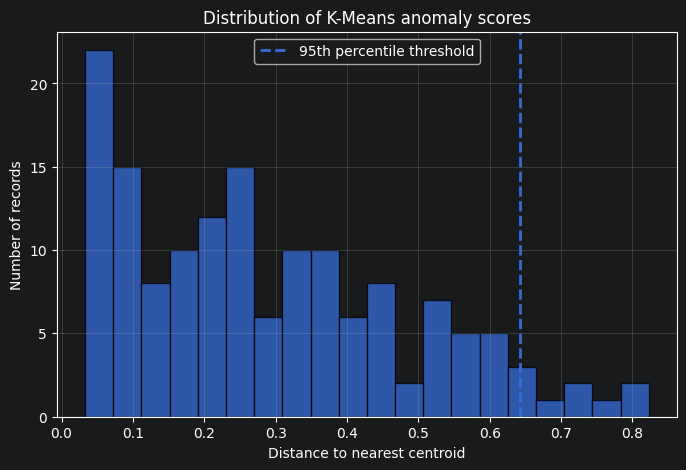

In [26]:
percentiles = [85, 90, 95, 97, 99]

for percentile in percentiles:
    current_threshold = np.percentile(anomaly_scores, percentile)
    current_anomalies = anomaly_scores > current_threshold
    print(
        f"Percentile {percentile:2d}: "
        f"threshold = {current_threshold:.3f}, "
        f"anomalies = {current_anomalies.sum():2d}"
    )

plt.figure(figsize=(8, 5))
plt.hist(anomaly_scores, bins=20, edgecolor='k', alpha=0.75)
plt.axvline(threshold, linestyle='--', linewidth=2, label='95th percentile threshold')
plt.xlabel('Distance to nearest centroid')
plt.ylabel('Number of records')
plt.title('Distribution of K-Means anomaly scores')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Add artificial extreme records to see anomaly detection clearly

The Iris dataset is clean and small, so its anomalies are not very dramatic.

For teaching purposes, we add a few artificial records with unusual petal measurements and check whether K-Means detects them.

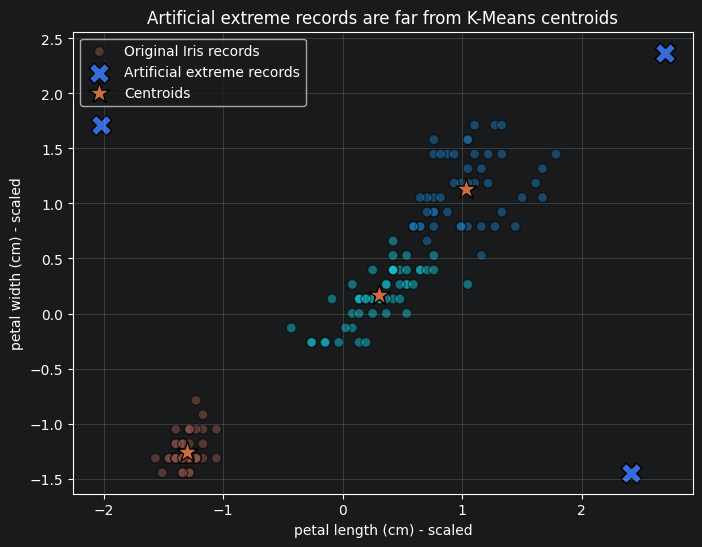

Artificial records:
record=[0.2 2.5], assigned_cluster=2, score=2.795, is_anomaly=True
record=[8.  0.1], assigned_cluster=2, score=2.652, is_anomaly=True
record=[8.5 3. ], assigned_cluster=0, score=2.079, is_anomaly=True


In [27]:
# Artificial records in original feature scale: [petal length, petal width]
artificial_records = np.array([
    [0.2, 2.5],  # very short but very wide petal
    [8.0, 0.1],  # very long but very narrow petal
    [8.5, 3.0],  # very large petal overall
])

X_extended = np.vstack([X, artificial_records])
X_extended_scaled = scaler.transform(X_extended)

extended_distances = kmeans_for_anomaly.transform(X_extended_scaled)
extended_scores = extended_distances.min(axis=1)
extended_clusters = extended_distances.argmin(axis=1)
extended_is_anomaly = extended_scores > threshold

plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=assigned_clusters,
    s=50,
    cmap='tab10',
    edgecolor='k',
    alpha=0.5,
    label='Original Iris records'
)

plt.scatter(
    X_extended_scaled[-len(artificial_records):, 0],
    X_extended_scaled[-len(artificial_records):, 1],
    s=220,
    marker='X',
    edgecolor='k',
    label='Artificial extreme records'
)

plt.scatter(
    kmeans_for_anomaly.cluster_centers_[:, 0],
    kmeans_for_anomaly.cluster_centers_[:, 1],
    s=250,
    marker='*',
    edgecolor='k',
    label='Centroids'
)

plt.xlabel(selected_feature_names[0] + ' - scaled')
plt.ylabel(selected_feature_names[1] + ' - scaled')
plt.title('Artificial extreme records are far from K-Means centroids')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Artificial records:")
for i, record in enumerate(artificial_records):
    extended_idx = len(X) + i
    print(
        f"record={record}, "
        f"assigned_cluster={extended_clusters[extended_idx]}, "
        f"score={extended_scores[extended_idx]:.3f}, "
        f"is_anomaly={extended_is_anomaly[extended_idx]}"
    )

# Part C: DBSCAN

DBSCAN means **Density-Based Spatial Clustering of Applications with Noise**.

Instead of asking for the number of clusters, DBSCAN asks for two density parameters:

- `eps`: radius around a point,
- `min_samples`: minimum number of points required to form a dense region.

DBSCAN can discover irregular cluster shapes and mark isolated points as noise with label `-1`.

## 11. DBSCAN with different `eps` values

The most important DBSCAN parameter is usually `eps`.

A small `eps` may create too many noise points. A large `eps` may merge clusters together.

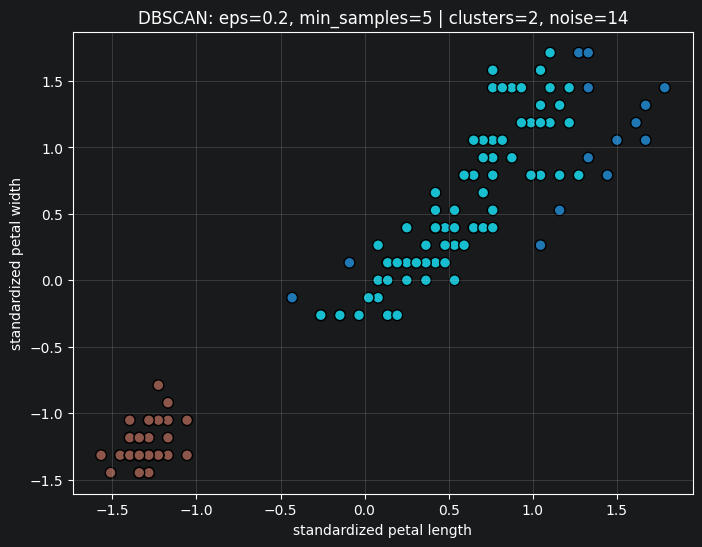

Silhouette score without noise: 0.7712622395757988
Adjusted Rand Index vs true labels: 0.5536115521735223
Labels: {np.int64(-1): np.int64(14), np.int64(0): np.int64(50), np.int64(1): np.int64(86)}


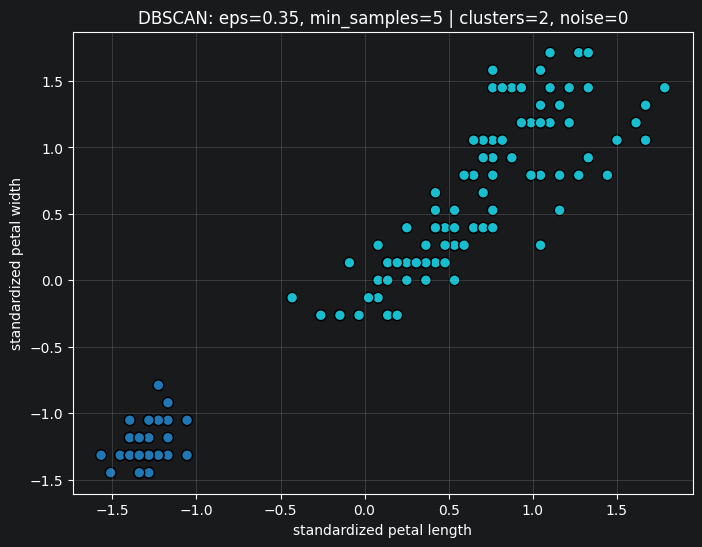

Silhouette score without noise: 0.743371950414545
Adjusted Rand Index vs true labels: 0.5681159420289855
Labels: {np.int64(0): np.int64(50), np.int64(1): np.int64(100)}


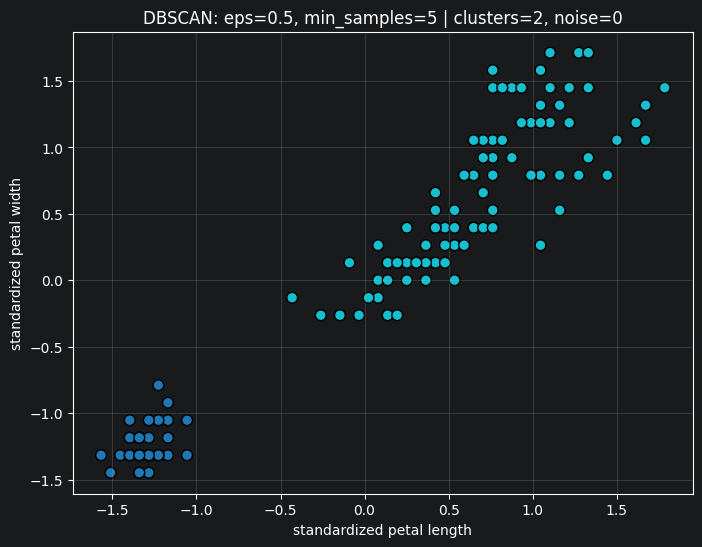

Silhouette score without noise: 0.743371950414545
Adjusted Rand Index vs true labels: 0.5681159420289855
Labels: {np.int64(0): np.int64(50), np.int64(1): np.int64(100)}


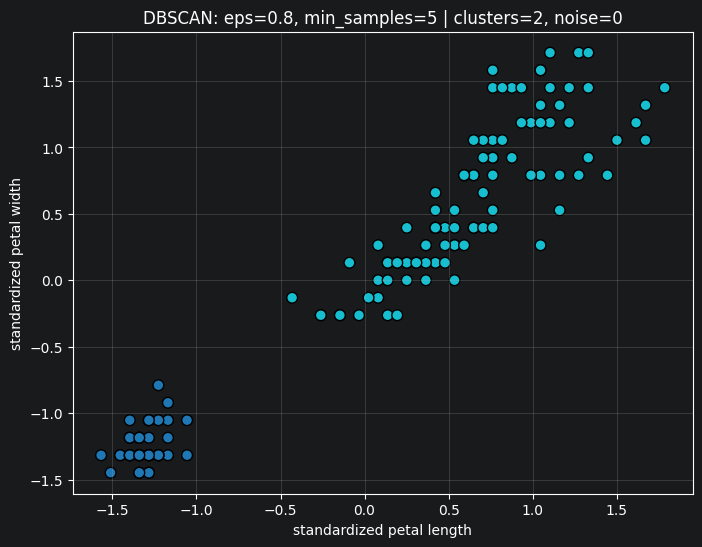

Silhouette score without noise: 0.743371950414545
Adjusted Rand Index vs true labels: 0.5681159420289855
Labels: {np.int64(0): np.int64(50), np.int64(1): np.int64(100)}


In [28]:
def plot_dbscan_result(X_data, eps, min_samples=5):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_data)

    unique_labels = sorted(set(labels))
    n_clusters = len([label for label in unique_labels if label != -1])
    n_noise = np.sum(labels == -1)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_data[:, 0], X_data[:, 1], c=labels, s=60, cmap='tab10', edgecolor='k')
    plt.xlabel('standardized petal length')
    plt.ylabel('standardized petal width')
    plt.title(f'DBSCAN: eps={eps}, min_samples={min_samples} | clusters={n_clusters}, noise={n_noise}')
    plt.grid(alpha=0.3)
    plt.show()

    if n_clusters >= 2 and len(set(labels)) > 1:
        non_noise_mask = labels != -1
        if len(set(labels[non_noise_mask])) > 1:
            print("Silhouette score without noise:", silhouette_score(X_data[non_noise_mask], labels[non_noise_mask]))
    print("Adjusted Rand Index vs true labels:", adjusted_rand_score(y_true, labels))
    print("Labels:", dict(zip(*np.unique(labels, return_counts=True))))

for eps in [0.2, 0.35, 0.5, 0.8]:
    plot_dbscan_result(X_scaled, eps=eps, min_samples=5)

## 12. Visual intuition for `eps`

The circle around a point represents the `eps` neighborhood.

DBSCAN checks how many points are inside such neighborhoods to decide whether a point is part of a dense area.

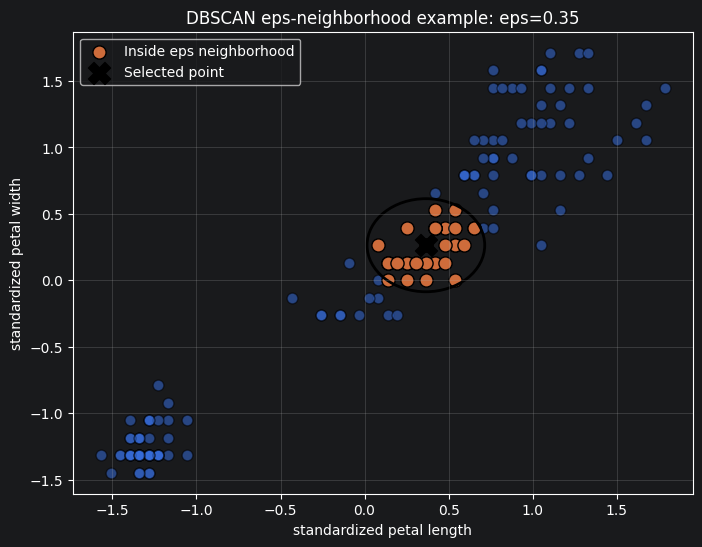

Points inside eps neighborhood: 35


In [29]:
point_index = 75
chosen_eps = 0.35
point = X_scaled[point_index]
distances = np.linalg.norm(X_scaled - point, axis=1)
inside_eps = distances <= chosen_eps

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], s=60, edgecolor='k', alpha=0.55)
ax.scatter(X_scaled[inside_eps, 0], X_scaled[inside_eps, 1], s=90, edgecolor='k', label='Inside eps neighborhood')
ax.scatter(point[0], point[1], marker='X', s=250, c='black', label='Selected point')

circle = plt.Circle(point, chosen_eps, fill=False, linewidth=2)
ax.add_patch(circle)

ax.set_xlabel('standardized petal length')
ax.set_ylabel('standardized petal width')
ax.set_title(f'DBSCAN eps-neighborhood example: eps={chosen_eps}')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("Points inside eps neighborhood:", inside_eps.sum())

## 13. K-Means vs DBSCAN: comparison

K-Means and DBSCAN make different assumptions.

| Algorithm | Strength | Limitation |
|---|---|---|
| K-Means | Simple, fast, easy to explain | Needs `k`; prefers round/spherical clusters |
| DBSCAN | Finds dense regions; detects noise | Sensitive to `eps`; struggles with varying densities |

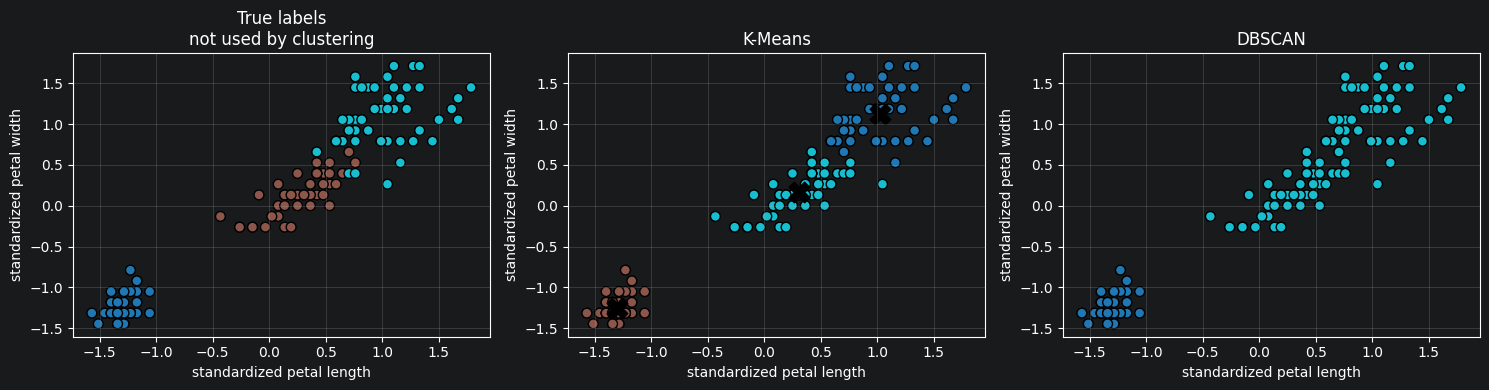

In [30]:
best_dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = best_dbscan.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, s=50, cmap='tab10', edgecolor='k')
axes[0].set_title('True labels\nnot used by clustering')

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, s=50, cmap='tab10', edgecolor='k')
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=220, c='black')
axes[1].set_title('K-Means')

axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, s=50, cmap='tab10', edgecolor='k')
axes[2].set_title('DBSCAN')

for ax in axes:
    ax.set_xlabel('standardized petal length')
    ax.set_ylabel('standardized petal width')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Optional: use all four Iris features

The plots above used two dimensions for teaching clarity. In real use, clustering can use all available features.

In [31]:
X_all_scaled = StandardScaler().fit_transform(X_all)

kmeans_all = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
kmeans_all_labels = kmeans_all.fit_predict(X_all_scaled)

# DBSCAN parameters are scale-sensitive. These values are only a starting point.
dbscan_all = DBSCAN(eps=0.9, min_samples=5)
dbscan_all_labels = dbscan_all.fit_predict(X_all_scaled)

print("K-Means on all features")
print("ARI:", adjusted_rand_score(y_true, kmeans_all_labels))
print("Silhouette:", silhouette_score(X_all_scaled, kmeans_all_labels))
print()

print("DBSCAN on all features")
print("ARI:", adjusted_rand_score(y_true, dbscan_all_labels))
print("Label counts:", dict(zip(*np.unique(dbscan_all_labels, return_counts=True))))

K-Means on all features
ARI: 0.6201351808870379
Silhouette: 0.45994823920518635

DBSCAN on all features
ARI: 0.5517553852833211
Label counts: {np.int64(-1): np.int64(4), np.int64(0): np.int64(49), np.int64(1): np.int64(97)}


## Summary

K-Means:

- starts with centroids,
- assigns points to nearest centroids,
- moves centroids to cluster means,
- requires choosing `k`,
- can be adapted for anomaly detection by measuring distance to the nearest centroid.

DBSCAN:

- searches for dense regions,
- uses `eps` and `min_samples`,
- can mark outliers as noise,
- does not require specifying the number of clusters directly.